For simplicity, exclude QSO targets.

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits
import healpy as hp

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_cumulative_lrg.fits'))
print(len(cat))

cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.33 * cat['TSNR2_LRG']

# Add NOBS columns
main_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0'
lrg = []
for field in ['north', 'south']:
    lrg.append(Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_{}_1.0.0_basic.fits'.format(field)), columns=['TARGETID', 'NOBS_G', 'NOBS_R', 'NOBS_Z'])))
lrg = vstack(lrg)
cat = join(cat, lrg, keys='TARGETID')
print(len(cat))

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 950.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers), 'bad fibers')
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Martin's EBV cut
mask = cat['EBV']<0.15
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's NOBS cut
mask = (cat['NOBS_G']>1) & (cat['NOBS_R']>1) & (cat['NOBS_Z']>1)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=2500
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['TARGET_RA'], cat['TARGET_DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(mask_bad), np.sum(~mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

346063
346063
FIBERSTATUS 340944 5119 0.014792104327824702
No data 340944 0 0.0
LRG mask 306665 34279 0.10054143789009339
Remove QSO targets 301954 4711 0.015362040011087017
Min depth 252767 49187 0.1628956728508316
199 bad fibers
Bad fibers 243215 9552 0.03778974312311338
EBV 242137 1078 0.0044322924161749894
NOBS 233406 8731 0.03605809934045602
STARDENS 10503 222903 0.04499884321739801
222903 222887 16
222887 222887 0


In [4]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum(~mask_quality)/len(mask_quality))

0.017923880710853483


In [5]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

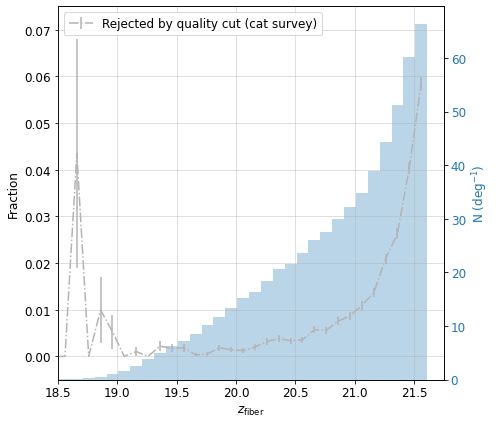

In [6]:
bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

area = len(cat)/600

mask = np.full(len(cat), True)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~mask_quality)[mask], bin_edges, minsize=10, error_floor=False)


fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', label='Rejected by quality cut (cat survey)', color='0.7')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
ax1.axis([18.5, 21.75, -0.005, 0.075])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['zfibermag'], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(len(cat), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
xdata = bin_center[10:].copy()
ydata = bin_reject_rate[10:].copy()
mask = np.isfinite(ydata)
xdata = xdata[mask]
ydata = ydata[mask]

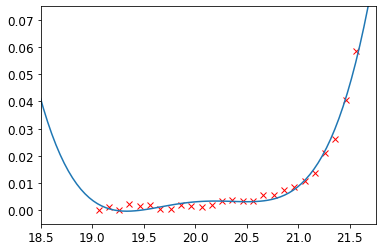

In [8]:
# Try polynomial

coeffs = np.polyfit(xdata, ydata, 4)
p = np.poly1d(coeffs)
x = np.linspace(18, 22, 100)
y = p(x)

plt.plot(xdata, ydata, 'rx')
plt.plot(x, y)
plt.axis([18.5, 21.75, -0.005, 0.075])
plt.show()

[3.2319795581242428, -18.47796832177645, 2.663839936815595e-06]


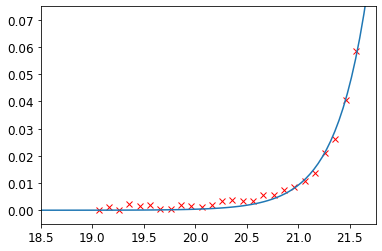

In [9]:
# Try exponential

from scipy.optimize import curve_fit

xdata = bin_center[10:].copy()
ydata = bin_reject_rate[10:].copy()
mask = np.isfinite(ydata)
xdata = xdata[mask]
ydata = ydata[mask]

def failure_rate_func(x, a, b, c):
    return np.clip(np.exp(a*(x + b)) * c, 0, 1)

popt, _ = curve_fit(failure_rate_func, xdata, ydata, p0=[3., -18., 1e-7], bounds=([3, -np.inf, -np.inf], [5, np.inf, np.inf]))
print(list(popt))

x = np.linspace(18, 22, 100)
y = failure_rate_func(x, *popt)

plt.plot(xdata, ydata, 'rx')
plt.axis([18.5, 21.75, -0.005, 0.075])
plt.plot(x, y)
plt.show()